# March Mania · Feature research

The first official-data benchmark is complete: 120 folds, with its original AWS run and checksums recorded in this repository.

**Status:** measured retrospective development evidence. The strength-only logistic candidate leads both compact benchmarks. The rebuilt notebook 02 tests the next feature families. Historical 2026 scores below are repository records, including post-result refinements.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
from march_mania.features import feature_blocks

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
RUN = ROOT / "outputs/research"
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
scores = pd.read_csv(ROOT / "reports/submission_portfolio/kaggle_scores.csv")
display(Markdown(f"**Best recorded observed Brier:** {scores.KaggleBrier.min():.7f}. "
                 "The approximately 0.121 result still requires its submission record."))
display(scores.sort_values("KaggleBrier").head(5))

**Best recorded observed Brier:** 0.1281386. The approximately 0.121 result still requires its submission record.

,Candidate,KaggleBrier,ObservedAtUTC,Notes
0,challenger_temperature_m_0p800_w_1p300,0.128139,2026-08-31T22:42:54.092158+00:00,Post-result challenger-temperature refinement:...
1,challenger_temperature_m_0p770_w_1p200,0.128496,2026-08-31T23:01:45.152818+00:00,Post-result challenger-temperature refinement:...
2,challenger_temperature_m_0p80_w_1p20,0.128533,2026-08-31T00:00:00Z,Candidate 05; best observed score in the scree...
3,challenger_temperature_m_0p770_w_1p220,0.128582,2026-08-31T22:48:22.814821+00:00,Post-result challenger-temperature refinement:...
4,challenger,0.129901,2026-08-31T00:00:00Z,Original challenger submission.


## Preserve the baseline

The larger historical system already contains hundreds of candidate features. We are testing whether particular signals help on matched folds, rather than interpreting feature count as model quality. The chart below is historical score evidence, not a comparison of newly trained models.

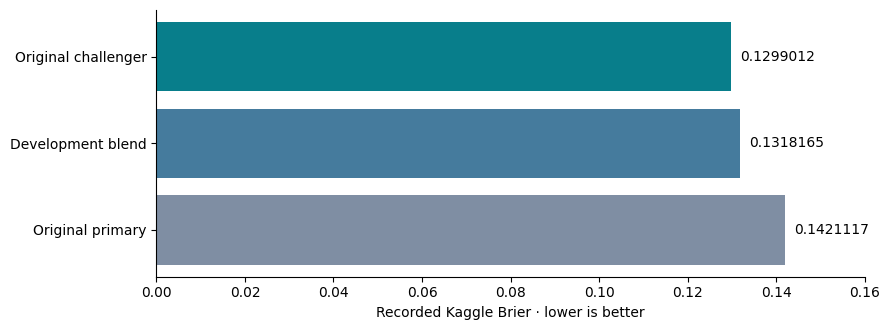

In [2]:
names = ["challenger", "development_blend", "primary"]
base = scores.set_index("Candidate").loc[names, "KaggleBrier"]
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(["Original challenger", "Development blend", "Original primary"], base,
        color=["#087e8b", "#457b9d", "#7f8ea3"])
ax.set_xlim(0, 0.16)
ax.set_xlabel("Recorded Kaggle Brier · lower is better")
ax.invert_yaxis()
for i, value in enumerate(base):
    ax.text(value + 0.002, i, f"{value:.7f}", va="center", fontsize=10)
fig.tight_layout()
display(fig)
plt.close(fig)

## Feature hypotheses and evaluation

Every candidate uses the same expanding-window folds and the same physical games. Pre-tournament features stop at DayNum 132. NCAA outcomes are labels only. Training-fold augmentation enforces complementary matchup probabilities.

The fixed logistic and shallow boosting recipes isolate feature effects. The nonlinear cross-team products are hypotheses, not promised gains. Existing 2022–2026 results remain outside this development experiment.

In [3]:
display(pd.DataFrame([{"Candidate": name, "Feature count": len(columns),
                       "Features": ", ".join(columns)}
                      for name, columns in feature_blocks().items()]))
config = json.loads((ROOT / "configs/research.json").read_text())
display(pd.DataFrame({"Setting": list(config), "Value": [str(v) for v in config.values()]}))

,Candidate,Feature count,Features
0,seed,1,diff_seed
1,strength,6,"diff_seed, diff_strength, diff_schedule_streng..."
2,efficiency,17,"diff_seed, diff_strength, diff_schedule_streng..."
3,recent,19,"diff_seed, diff_strength, diff_schedule_streng..."
4,matchup,23,"diff_seed, diff_strength, diff_schedule_streng..."
5,full,25,"diff_seed, diff_strength, diff_schedule_streng..."


,Setting,Value
0,protocol,retrospective-feature-research
1,first_training_season,2013
2,validation_seasons,"[2016, 2017, 2018, 2019, 2021]"
3,feature_cutoff_day,132
4,minimum_prior_seasons,3
5,include_play_in,True
6,ridge_alpha,20.0
7,recent_half_life_days,30.0
8,seed,2026
9,threads,2


## Run and resume

The recorded notebook 05 run is complete. Review its evidence below. Use the Kaggle download and rebuilt feature-store commands in `docs/feature_store.md` for the next experiment. Repeat the same command after interruption; completed checksum-valid tasks are reused. Training is not triggered by opening this notebook.

In [4]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, HTML

result_dir = ROOT / "outputs/research"
if not (result_dir / "summary.json").exists():
    result_dir = ROOT / "reports/research"
    evidence = json.loads((result_dir / "run.json").read_text())
    summary = evidence["summary"]
    import hashlib
    for name, expected in evidence["sha256"].items():
        assert hashlib.sha256((result_dir / name).read_bytes()).hexdigest() == expected, name
else:
    summary = json.loads((result_dir / "summary.json").read_text())
assert summary["status"] == "completed", "The selected run is not complete"
display(Markdown(f"**Verified official-data run:** {summary['fold_tasks']} folds in {summary['elapsed_seconds']:.3f}s. Fingerprint: `{summary['fingerprint']}`."))
leaderboard = pd.read_csv(result_dir / "leaderboard.csv")
display(HTML(leaderboard.query("model == 'logistic' and block in ['seed','strength','full']")
             [["Gender","block","macro_season_brier","brier","log_loss","games"]]
             .to_html(index=False, float_format=lambda value: f"{value:.6f}")))
display(Markdown("**Decision:** strength logistic leads both compact benchmarks. Adding all 25 features worsens both. The next experiment is the rebuilt canonical notebook 02; these results do not establish a new Kaggle score."))


**Verified official-data run:** 120 folds in 31.545s. Fingerprint: `b0ca1fe8efba1b73a689623d9ae3e6c79de9ff3a1c925a9967e74bce9ae0049d`.

Gender,block,macro_season_brier,brier,log_loss,games
M,full,0.192310,0.192246,0.562969,334
M,seed,0.200158,0.200083,0.583692,334
M,strength,0.191268,0.191184,0.558170,334
W,full,0.153326,0.153326,0.462679,315
W,seed,0.151179,0.151179,0.459379,315
W,strength,0.144308,0.144308,0.433855,315


**Decision:** strength logistic leads both compact benchmarks. Adding all 25 features worsens both. The next experiment is the rebuilt canonical notebook 02; these results do not establish a new Kaggle score.

## Decision gate

Before claiming an improvement: reconcile the recalled submission score; reproduce the seed baseline; compare models on identical IDs; inspect men's and women's season variability and calibration; require useful paired ablations; then tune/calibrate only within chronological inner folds. Freeze a prospective recipe before the next tournament.

Historical external ratings and timestamped player availability are the next data priorities. Their historical availability and licensing must be established before using them in validation.